### get data

In [40]:
import pandas as pd
import numpy as np
import talib.abstract as ta
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# turn on dfnet
# hasattr(exchange, 'set_sandbox_mode')
exchange.set_sandbox_mode(True)

In [41]:
df = pd.DataFrame(exchange.fetch_ohlcv(symbol='AAVEUSDT', timeframe='4h', limit= 1000))
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df.Date= pd.to_datetime(df.Date, unit='ms')
# 定义价格异常的条件，例如价格为负数或超出合理范围
price_columns = ['Open', 'High', 'Low', 'Close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()


c:\Users\xlfin\anaconda3\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


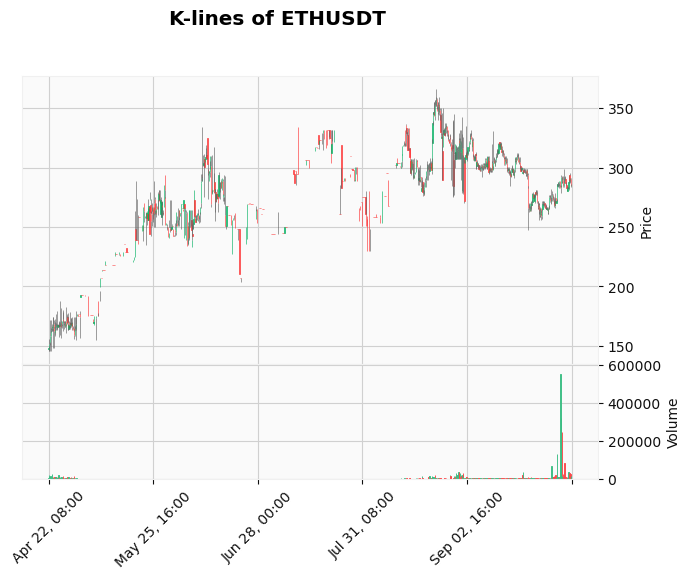

In [42]:
import mplfinance as mpf

# Prepare the data for mplfinance
df_for_mpf = df.set_index('Date')[['Open', 'High', 'Low', 'Close', 'Volume']]

# Plot the K-lines
mpf.plot(
    df_for_mpf,
    type='candle',
    volume=True,
    style='yahoo',
    title='K-lines of ETHUSDT',
    ylabel='Price',
    ylabel_lower='Volume'
)

### processing

In [ ]:
# calc BIAS indicator
def BIAS_percentile(dataframe:pd.DataFrame, baseline_period= 144, percentile_window= 233):
    dataframe['tp'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    dataframe['MA_144'] = ta.MA(dataframe['tp'], timeperiod=baseline_period)
    dataframe['BIAS'] = (dataframe['tp'] - dataframe['MA_144']) / dataframe['MA_144'] * 100
    dataframe['BIAS_percentile'] = dataframe['BIAS'].rolling(window=percentile_window).apply(
        lambda x: (x.rank(pct=True)).iloc[-1] * 100 if len(x) == percentile_window else np.nan
    )
    dataframe['BIAS_zscore'] = (dataframe['BIAS'] - dataframe['BIAS'].rolling(window=zscore_window).mean()) / dataframe['BIAS'].rolling(window=zscore_window).std()
    return dataframe


In [ ]:
# BIAS z-score
def BIAS_zscore(dataframe:pd.DataFrame, baseline_period= 144, zscore_window= 233):
    dataframe['tp'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    dataframe['MA_144'] = ta.MA(dataframe['tp'], timeperiod=baseline_period)
    dataframe['BIAS'] = (dataframe['tp'] - dataframe['MA_144']) / dataframe['MA_144'] * 100
    dataframe['BIAS_zscore'] = (dataframe['BIAS'] - dataframe['BIAS'].rolling(window=zscore_window).mean()) / dataframe['BIAS'].rolling(window=zscore_window).std()
    return dataframe

# dataframe['BIAS_zscore'] = (dataframe['BIAS'] - dataframe['BIAS'].rolling(377).mean()) / dataframe['BIAS'].rolling(377).std()


In [56]:
# draw lines for both tp_BIAS and close_BIAS as subplots
import mplfinance as mpf
def plot_BIAS(dataframe:pd.DataFrame):
    # clal BIAS_Zscore 
    zscore_window= 377 # baseline_window* 2.618
    dataframe['BIAS_zscore'] = (dataframe['BIAS'] - dataframe['BIAS'].rolling(window=zscore_window).mean()) / dataframe['BIAS'].rolling(window=zscore_window).std()

    df_for_mpf = dataframe.set_index('Date')[['Open', 'High', 'Low', 'Close', 'MA_144', 'BIAS_percentile', 'BIAS_zscore']].tail(500).copy()
    ap = [
        mpf.make_addplot(df_for_mpf['BIAS_percentile'], panel=1, color='blue', ylabel='tp_BIAS'),
        mpf.make_addplot(df_for_mpf['MA_144'], color='orange', ylabel='MA144'),
        # plot BIAS_zscore
        mpf.make_addplot(df_for_mpf['BIAS_zscore'], panel=2, color='red', ylabel='BIAS_zscore')
    ]
    mpf.plot(
        df_for_mpf,
        type='candle',
        volume= False,
        style='yahoo',
        title='K-lines of ETHUSDT with BIAS',
        ylabel='Price',
        ylabel_lower='Volume',
        addplot=ap,
        panel_ratios=(3,1,1),
        figsize=(16,10)
    )
    return


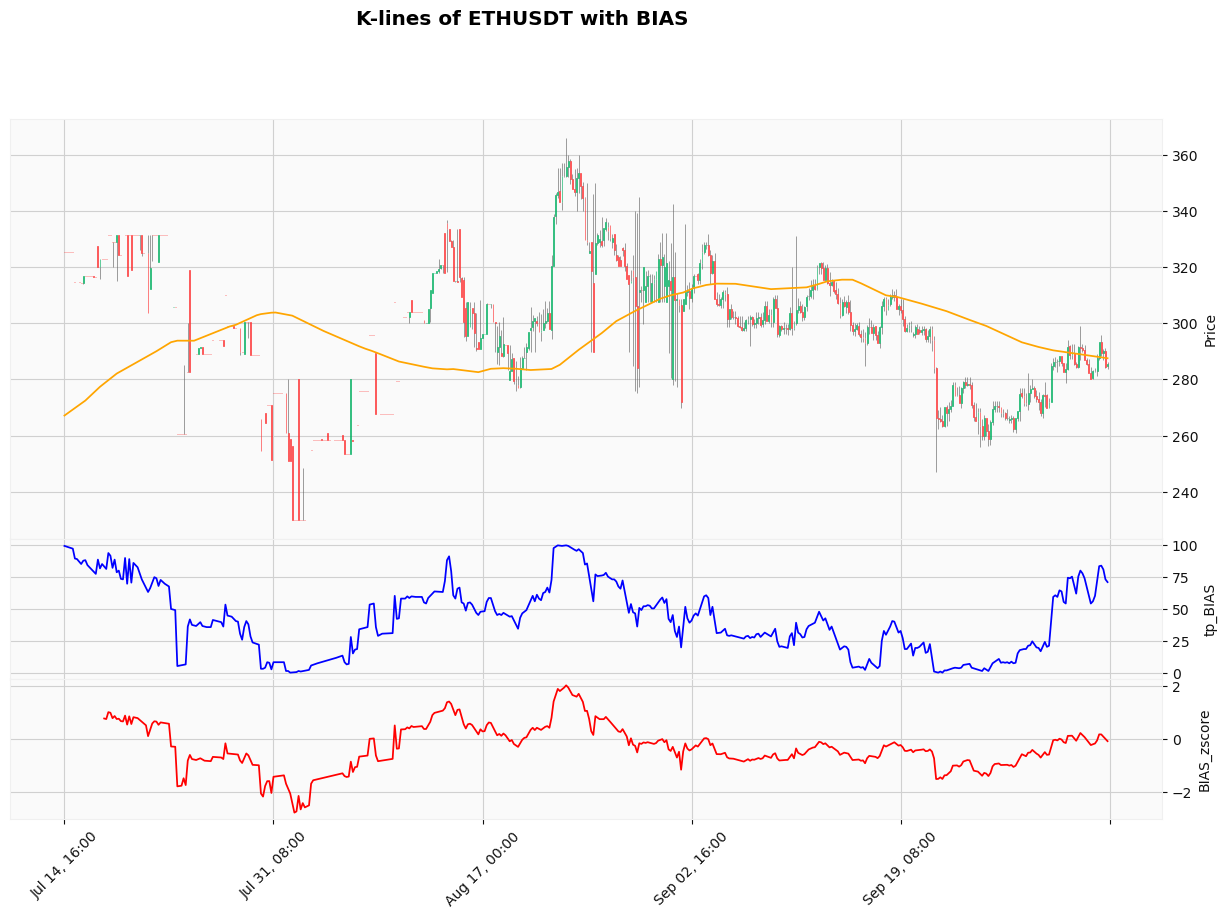

In [57]:
plot_BIAS(BIAS_percentile(df))

In [4]:
# Calculate EMA(144)
# df['ema_144'] = ta.EMA(df['Close'], timeperiod=144)
df['ewa_144'] = df['Close'].ewm(span=144, adjust=False).mean()

# Calculate BIAS
# df['BIAS'] = (df['Close'] - df['ema_144']) / df['ema_144'] * 100
df['BIAS_ewa'] = (df['Close'] - df['ewa_144']) / df['ewa_144'] * 100

# df[['Date', 'Close', 'BIAS', 'BIAS_ewa']].tail(20)
df.tail(20)

,Date,Open,High,Low,Close,Volume,ewa_144,BIAS_ewa
980,2025-10-02 00:00:00,286.60,288.34,284.76,288.33,9464.8,286.101326,0.778981
981,2025-10-02 04:00:00,288.34,288.44,284.86,285.69,4754.0,286.095653,-0.141789
982,2025-10-02 08:00:00,285.69,285.72,282.54,282.80,11961.3,286.050195,-1.136233
983,2025-10-02 12:00:00,282.80,285.72,278.89,283.81,551627.3,286.019296,-0.772429
984,2025-10-02 16:00:00,283.78,294.01,283.30,291.70,321470.7,286.097651,1.958195
985,2025-10-02 20:00:00,291.71,292.38,287.21,288.78,245795.1,286.134649,0.924513
986,2025-10-03 00:00:00,288.77,292.66,287.12,289.58,13790.9,286.182171,1.187296
987,2025-10-03 04:00:00,289.53,292.68,285.03,285.41,24569.3,286.171520,-0.266106
988,2025-10-03 08:00:00,285.38,286.25,283.89,284.42,7028.1,286.147361,-0.603661
989,2025-10-03 12:00:00,284.52,291.72,283.89,291.60,34937.5,286.222570,1.878758


In [5]:
# the last 1000 rows, find the percentile of BIAS_ewa
df['BIAS_ewa_percentile'] = df['BIAS_ewa'].rank(pct=True) * 100

In [6]:
df.tail(10)

,Date,Open,High,Low,Close,Volume,ewa_144,BIAS_ewa,BIAS_ewa_percentile
990,2025-10-03 16:00:00,291.62,299.17,286.74,291.16,85180.3,286.290672,1.700833,40.7
991,2025-10-03 20:00:00,291.16,292.67,289.72,290.44,8361.6,286.347905,1.429064,39.7
992,2025-10-04 00:00:00,290.47,292.36,286.83,286.97,8912.4,286.356485,0.214249,35.3
993,2025-10-04 04:00:00,286.97,287.52,285.21,285.55,4995.8,286.345361,-0.277763,33.6
994,2025-10-04 08:00:00,285.50,287.19,282.39,282.43,6468.3,286.291356,-1.348751,28.6
995,2025-10-04 12:00:00,282.43,284.57,280.11,280.26,8512.6,286.208165,-2.078265,27.3
996,2025-10-04 16:00:00,280.38,283.23,280.11,282.91,4587.0,286.162673,-1.136652,29.1
997,2025-10-04 20:00:00,282.91,283.91,282.66,283.05,3951.6,286.119740,-1.072886,29.4
998,2025-10-05 00:00:00,283.06,289.17,281.04,287.50,33067.3,286.138778,0.475721,36.3
999,2025-10-05 04:00:00,287.49,290.45,286.74,290.45,5661.9,286.198243,1.485599,39.9


In [6]:
lookback_period = 233       # Define the rolling window size
df['BIAS_ewa_rolling_percentile'] = df['BIAS_ewa'].rolling(window=lookback_period).apply(
    lambda x: (x.rank(pct=True).iloc[-1] * 100) if len(x) == lookback_period else np.nan,
    raw=False
)

In [7]:
df.tail(100)

,Date,Open,High,Low,Close,Volume,ewa_144,BIAS_ewa,BIAS_ewa_percentile,BIAS_ewa_rolling_percentile
900,2025-09-17 12:00:00,1.9814,1.9965,1.9677,1.9871,8879.3,2.007638,-1.023017,23.9,23.175966
901,2025-09-17 16:00:00,1.9853,2.0260,1.9715,2.0108,192627.9,2.007682,0.155299,45.1,30.472103
902,2025-09-17 20:00:00,2.0108,2.0698,1.9941,2.0627,103945.6,2.008441,2.701550,66.7,42.489270
903,2025-09-18 00:00:00,2.0645,2.0781,2.0538,2.0651,52765.8,2.009222,2.781053,67.1,43.347639
904,2025-09-18 04:00:00,2.0653,2.0795,2.0302,2.0553,95331.8,2.009858,2.260955,64.8,42.060086
...,...,...,...,...,...,...,...,...,...,...
995,2025-10-03 08:00:00,1.9356,2.1110,1.9356,2.0779,36159272.0,1.866794,11.308469,81.6,93.991416
996,2025-10-03 12:00:00,2.0779,2.1381,1.7500,1.9258,62174161.8,1.867608,3.115856,68.4,78.540773
997,2025-10-03 16:00:00,1.9255,1.9609,1.8645,1.8946,46051494.6,1.867980,1.425051,60.4,71.244635
998,2025-10-03 20:00:00,1.8946,1.9172,1.8761,1.8761,9028245.4,1.868092,0.428655,49.8,64.377682


In [7]:
import mplfinance as mpf

# Prepare the data for mplfinance
df_for_mpf = df.set_index('Date')
# Plot the K-lines with two subplots
mpf.plot(
    df_for_mpf,
    type='candle',
    volume=False,
    style='yahoo',
    addplot=[
        mpf.make_addplot(df_for_mpf['BIAS_ewa_percentile'], panel=1, color='blue', ylabel='Percentile'),
        mpf.make_addplot(df_for_mpf['BIAS_ewa_rolling_percentile'], panel=1, color='red', ylabel='Percentile')
    ],
    title='K-lines with Percentile',
    ylabel='Price',
    ylabel_lower='Volume',
    figsize=(16, 10)  # Set the figure size
)


KeyError: 'BIAS_ewa_rolling_percentile'

c:\Users\xlfin\anaconda3\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


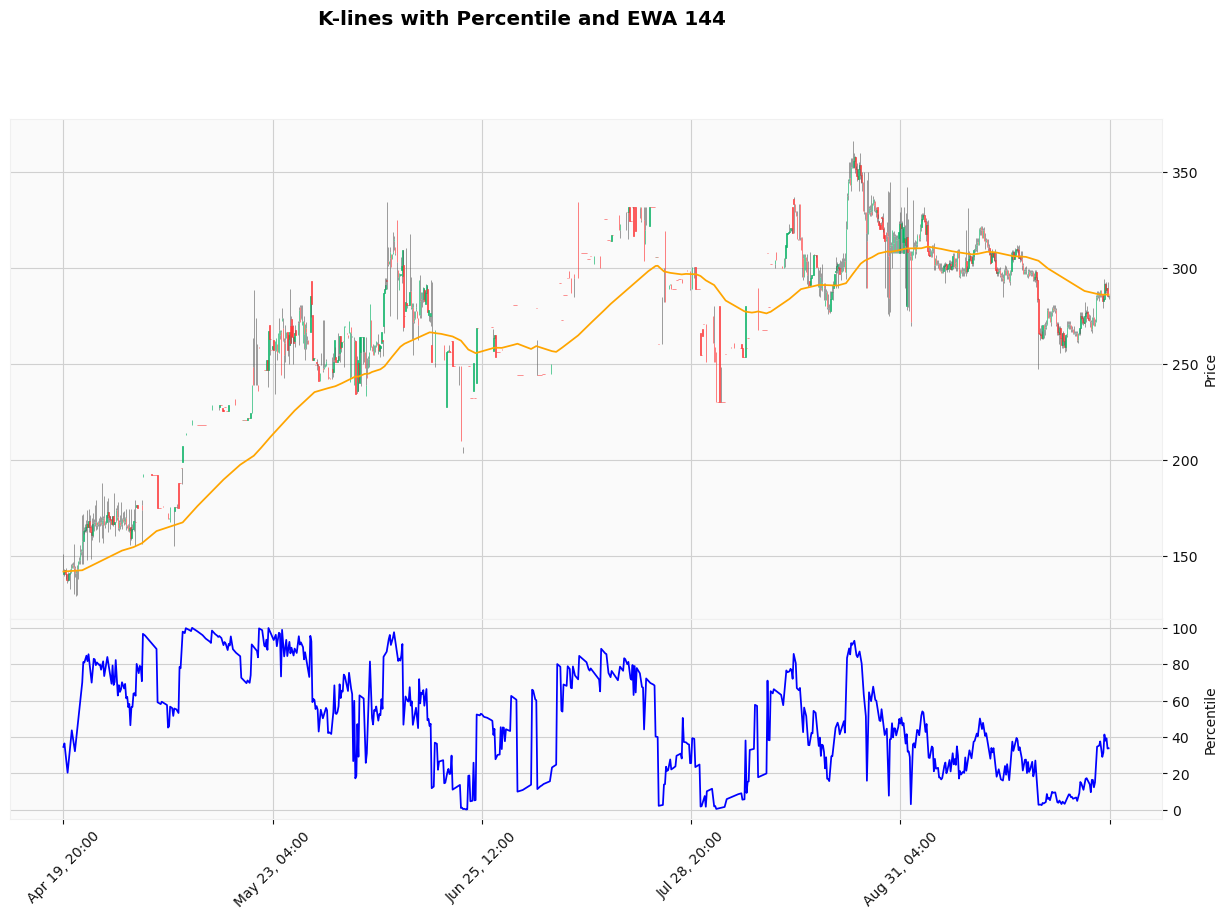

In [26]:
# Plot the K-lines with a larger figure and include the ewa_144 line
mpf.plot(
    df_for_mpf,
    type='candle',
    volume=False,
    style='yahoo',
    addplot=[
        mpf.make_addplot(df_for_mpf['BIAS_ewa_percentile'], panel=1, color='blue', ylabel='Percentile'),
        mpf.make_addplot(df_for_mpf['ewa_144'], color='orange', ylabel='EWA 144'),
    ],
    title='K-lines with Percentile and EWA 144',
    ylabel='Price',
    ylabel_lower='Volume',
    figsize=(16, 10)  # Set the figure size
)

In [ ]:
slice = df.iloc[-14:]
slice

,Date,Open,High,Low,Close,Volume
36154,2021-10-06 20:00:00,55049.99,55386.86,54812.00,54918.24,2562.022010
36155,2021-10-06 21:00:00,54918.24,55273.83,54880.05,55075.37,1617.265880
36156,2021-10-06 22:00:00,55075.38,55280.00,54893.02,55144.72,1516.958190
36157,2021-10-06 23:00:00,55144.72,55750.00,55119.08,55315.00,2887.609264
36158,2021-10-07 00:00:00,55315.00,55332.31,54500.00,54794.88,3291.494880
36159,2021-10-07 01:00:00,54794.88,54909.19,54112.00,54787.30,2806.591760
36160,2021-10-07 02:00:00,54787.30,55230.60,54680.92,55075.56,1938.382900
36161,2021-10-07 03:00:00,55075.57,55215.67,54730.86,54810.94,1540.734810
36162,2021-10-07 04:00:00,54810.93,55237.04,54756.06,55073.20,1450.003900
36163,2021-10-07 05:00:00,55073.20,55073.21,54545.07,54735.76,2251.122020
